# demo_agents026 – Autonomous Incident Diagnosis & Resolution Agent

This is the polished demo notebook for the AGENTS026 prototype. It is designed for walkthrough/demo usage rather than development.

Recommended flow during the demo:
1. Briefly explain the problem and generated telemetry.
2. Show anomaly detection and incident candidates.
3. Show similarity search over historical incidents and runbooks.
4. Run RCA + remediation for one incident.
5. Show final report and KB growth.

This notebook also captures step-level timings and basic GPU usage snapshots for technical credibility.


## Setup – Imports, Paths, and Metrics Helpers

Load all previously generated artifacts and define helper functions for timing and GPU snapshots.


In [1]:
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any
import os
import json
import time
import subprocess
from contextlib import contextmanager

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
incidents_dir = data_dir / 'incidents'
exec_dir = data_dir / 'execution'
vector_dir = data_dir / 'vectorstore'
reports_dir = data_dir / 'reports'
kb_dir = data_dir / 'kb'

metrics_log = []

def gpu_snapshot() -> Dict[str, str]:
    cmds = [
        'rocm-smi --showuse --showmemuse --showtemp --csv',
        'amd-smi monitor --csv',
    ]
    for cmd in cmds:
        try:
            out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True, timeout=20)
            return {'command': cmd, 'output': out[:4000]}
        except Exception:
            continue
    return {'command': 'unavailable', 'output': 'No GPU monitoring command available in PATH'}

@contextmanager
def timed_step(step_name: str):
    t0 = time.perf_counter()
    gpu_before = gpu_snapshot()
    yield
    elapsed = time.perf_counter() - t0
    gpu_after = gpu_snapshot()
    metrics_log.append({
        'step': step_name,
        'elapsed_sec': round(elapsed, 4),
        'gpu_before_cmd': gpu_before['command'],
        'gpu_before': gpu_before['output'],
        'gpu_after_cmd': gpu_after['command'],
        'gpu_after': gpu_after['output'],
    })

print('Setup complete')


Setup complete


## Load Artifacts

Read the outputs created by earlier notebooks. This demo notebook assumes the hour-by-hour notebooks have already been executed successfully.


In [2]:
with open(incidents_dir / 'incident_candidates.json', 'r', encoding='utf-8') as f:
    incident_candidates_raw = json.load(f)

with open(incidents_dir / 'rca_results.json', 'r', encoding='utf-8') as f:
    rca_results_raw = json.load(f)

metrics_df = pd.read_csv(data_dir / 'metrics.csv', parse_dates=['timestamp'])
logs_df = pd.read_csv(data_dir / 'app_logs.csv', parse_dates=['timestamp'])
changes_df = pd.read_csv(data_dir / 'change_events.csv', parse_dates=['timestamp'])
incident_table_df = pd.DataFrame([{
    'incident_id': x['incident_id'],
    'service': ','.join(x['services']),
    'anomaly_type': x['anomaly_type'],
    'start_time': x['start_time'],
    'end_time': x['end_time'],
    'cpu_max': x.get('metric_summary', {}).get('cpu_max'),
    'latency_p95_max': x.get('metric_summary', {}).get('latency_p95_max'),
    'error_rate_max': x.get('metric_summary', {}).get('error_rate_max'),
} for x in incident_candidates_raw])

workflow_summary_df = pd.read_parquet(exec_dir / 'workflow_summary.parquet') if (exec_dir / 'workflow_summary.parquet').exists() else pd.DataFrame()
report_summary_df = pd.read_parquet(reports_dir / 'report_summary.parquet') if (reports_dir / 'report_summary.parquet').exists() else pd.DataFrame()
kb_df = pd.read_parquet(kb_dir / 'resolved_incidents_kb.parquet') if (kb_dir / 'resolved_incidents_kb.parquet').exists() else pd.DataFrame()

len(incident_candidates_raw), len(rca_results_raw), len(kb_df)


(14, 3, 2)

## Section 1 – Problem & Data Overview

This section frames the AIOps problem and summarizes the generated telemetry used in the demo.


In [3]:
display(Markdown('''
### Why this matters
Modern microservice environments generate high-volume metrics, logs, deployment events, and infra signals.
During an outage, SREs need to: detect anomalies, correlate signals, retrieve similar incidents, infer likely root cause, propose actions, and capture post-incident knowledge.

### Demo data
- Services: checkout-api, catalog-api, payments-service, auth-service
- Telemetry: CPU, RPS, p95 latency, error rate
- Context: application logs, K8s-style events, deploy/config changes
- Workflow: anomaly detection → incident construction → retrieval → RCA → remediation → reporting → KB update
'''))

overview = {
    'metrics_rows': len(metrics_df),
    'logs_rows': len(logs_df),
    'changes_rows': len(changes_df),
    'incident_candidates': len(incident_candidates_raw),
    'resolved_kb_rows': len(kb_df),
}
pd.DataFrame([overview])



### Why this matters
Modern microservice environments generate high-volume metrics, logs, deployment events, and infra signals.
During an outage, SREs need to: detect anomalies, correlate signals, retrieve similar incidents, infer likely root cause, propose actions, and capture post-incident knowledge.

### Demo data
- Services: checkout-api, catalog-api, payments-service, auth-service
- Telemetry: CPU, RPS, p95 latency, error rate
- Context: application logs, K8s-style events, deploy/config changes
- Workflow: anomaly detection → incident construction → retrieval → RCA → remediation → reporting → KB update


,metrics_rows,logs_rows,changes_rows,incident_candidates,resolved_kb_rows
0,964,1007,17,14,2


In [4]:
with timed_step('problem_data_overview'):
    service_counts = metrics_df.groupby('service').size().reset_index(name='metric_points')
display(service_counts)


,service,metric_points
0,auth-service,241
1,catalog-api,241
2,checkout-api,241
3,payments-service,241


## Section 2 – Anomaly Detection & Incident List

Show the detected incidents and one representative metric chart.


In [5]:
with timed_step('incident_list_view'):
    display(incident_table_df.sort_values(['service', 'start_time']).head(20))


,incident_id,service,anomaly_type,start_time,end_time,cpu_max,latency_p95_max,error_rate_max
0,inc-001,auth-service,error_rate,2026-06-10 13:00:00,2026-06-10 13:15:00,16.281092,140.974418,0.112494
1,inc-002,catalog-api,error_rate,2026-06-10 11:53:00,2026-06-10 11:53:00,42.632146,203.290039,0.002410
2,inc-003,catalog-api,error_rate,2026-06-10 12:05:00,2026-06-10 12:05:00,40.199825,185.341948,0.001593
3,inc-004,catalog-api,error_rate,2026-06-10 12:20:00,2026-06-10 12:25:00,41.748616,188.118066,0.001110
4,inc-005,catalog-api,error_rate,2026-06-10 12:39:00,2026-06-10 12:49:00,38.334177,197.834246,0.001963
5,inc-006,catalog-api,error_rate,2026-06-10 12:57:00,2026-06-10 13:00:00,36.252084,180.255866,0.002201
6,inc-007,catalog-api,error_rate,2026-06-10 13:06:00,2026-06-10 13:08:00,30.395775,168.853485,0.003031
7,inc-008,catalog-api,error_rate,2026-06-10 13:14:00,2026-06-10 13:14:00,35.703629,157.570603,0.003703
8,inc-009,checkout-api,cpu,2026-06-10 11:00:00,2026-06-10 11:20:00,100.000000,163.757426,0.006353
9,inc-010,checkout-api,error_rate,2026-06-10 12:04:00,2026-06-10 12:04:00,39.898091,116.817631,0.003561


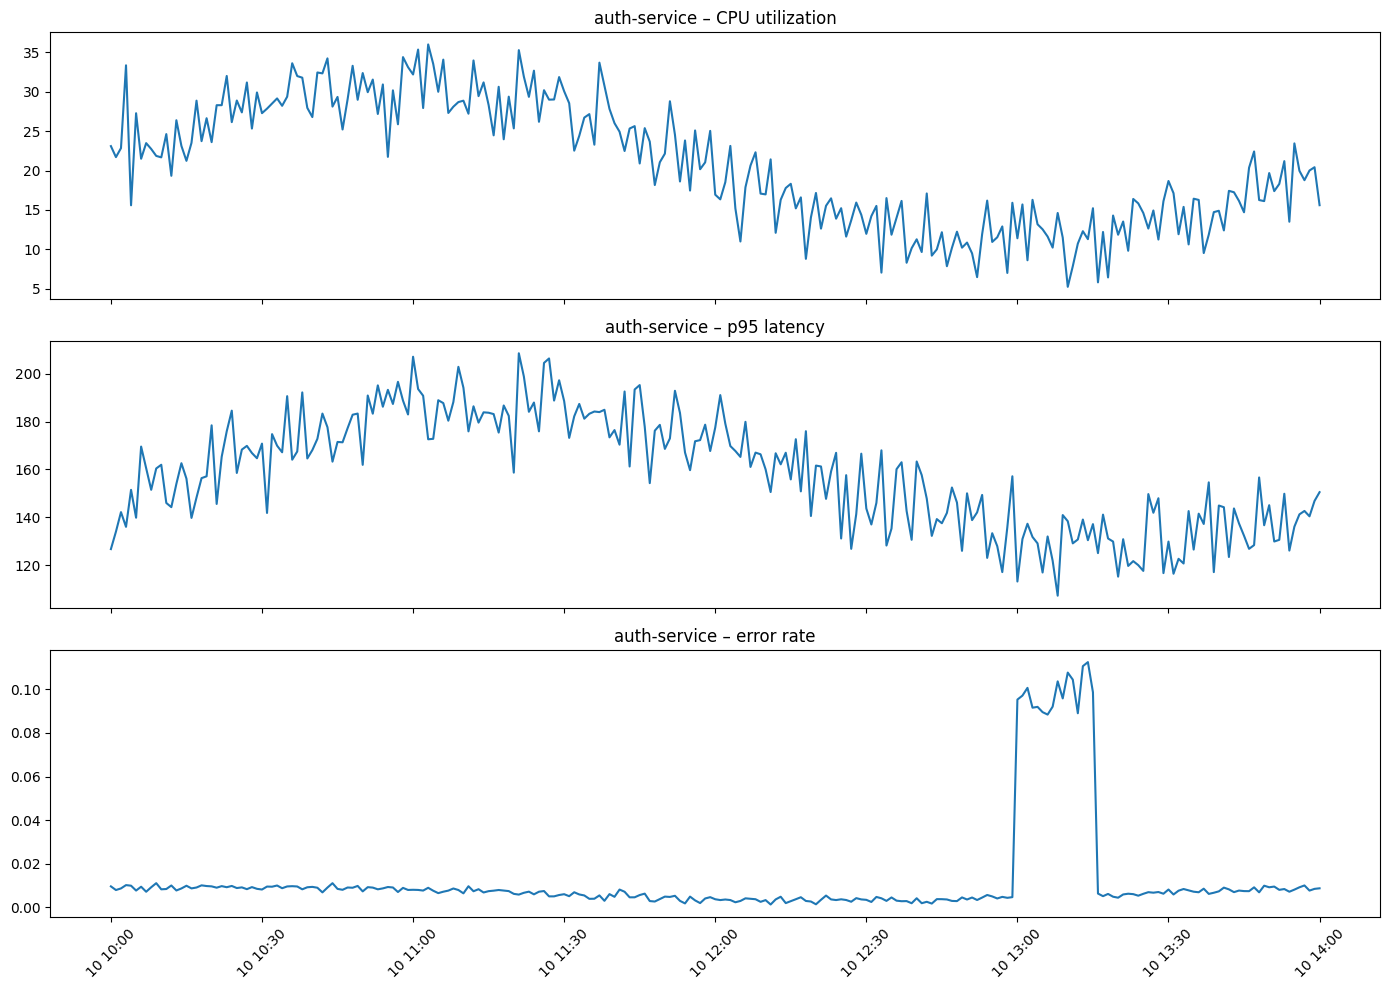

In [6]:
chosen_service = incident_table_df['service'].iloc[0] if not incident_table_df.empty else 'checkout-api'
svc_df = metrics_df[metrics_df['service'] == chosen_service].sort_values('timestamp').copy()

with timed_step('anomaly_plot'):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(svc_df['timestamp'], svc_df['cpu_utilization'])
    axes[0].set_title(f'{chosen_service} – CPU utilization')
    axes[1].plot(svc_df['timestamp'], svc_df['latency_p95_ms'])
    axes[1].set_title(f'{chosen_service} – p95 latency')
    axes[2].plot(svc_df['timestamp'], svc_df['error_rate'])
    axes[2].set_title(f'{chosen_service} – error rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Section 3 – Similarity Search Example

Show how the system retrieves relevant historical incidents/runbooks/KB entries for a chosen incident.


In [7]:
import faiss
from sentence_transformers import SentenceTransformer
import torch

corpus_df = pd.read_parquet(vector_dir / 'incident_runbook_metadata.parquet')
faiss_index = faiss.read_index(str(vector_dir / 'incident_runbook.index'))
embed_device = 'cuda' if torch.cuda.is_available() else 'cpu'
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=embed_device)

def embed_texts(texts, batch_size=16):
    return embed_model.encode(texts, batch_size=batch_size, convert_to_numpy=True, normalize_embeddings=True).astype('float32')

def search_similar_text(query_text: str, top_k: int = 5) -> pd.DataFrame:
    q = embed_texts([query_text], batch_size=1)
    scores, ids = faiss_index.search(q, top_k)
    rows = []
    for score, idx in zip(scores[0], ids[0]):
        if idx == -1:
            continue
        row = corpus_df.iloc[int(idx)].to_dict()
        row['score'] = float(score)
        rows.append(row)
    return pd.DataFrame(rows)


In [9]:
chosen_incident = incident_candidates_raw[0] if incident_candidates_raw else None
if chosen_incident:
    query_text = f"service={','.join(chosen_incident['services'])}; anomaly={chosen_incident['anomaly_type']}; logs={' | '.join(chosen_incident.get('log_samples', [])[:3])}"
    with timed_step('similarity_search'):
        sim_df = search_similar_text(query_text, top_k=8)
    display(sim_df[['doc_id', 'doc_type', 'service', 'title', 'score']])
else:
    print('No incident candidates available')


,doc_id,doc_type,service,title,score
0,inc-001,incident_candidate,auth-service,Incident candidate inc-001,0.827833
1,inc-009,incident_candidate,checkout-api,Incident candidate inc-009,0.681686
2,inc-014,incident_candidate,payments-service,Incident candidate inc-014,0.590739
3,inc-013,incident_candidate,checkout-api,Incident candidate inc-013,0.579738
4,inc-010,incident_candidate,checkout-api,Incident candidate inc-010,0.579526
5,inc-011,incident_candidate,checkout-api,Incident candidate inc-011,0.579417
6,inc-012,incident_candidate,checkout-api,Incident candidate inc-012,0.578373
7,hist-003,historical_incident,auth-service,Auth failures after config change,0.577112


## Section 4 – RCA + Remediation Run

Show the output of RCA and the resulting remediation/execution workflow for one chosen incident.


In [10]:
workflow_files = sorted(exec_dir.glob('*_workflow.json'))
workflow_bundles = []
for fp in workflow_files:
    with open(fp, 'r', encoding='utf-8') as f:
        workflow_bundles.append(json.load(f))

workflow_map = {x['incident_id']: x for x in workflow_bundles}
chosen_incident_id = chosen_incident['incident_id'] if chosen_incident else None

with timed_step('rca_remediation_display'):
    if chosen_incident_id in workflow_map:
        bundle = workflow_map[chosen_incident_id]
        display(Markdown(f"### RCA for {chosen_incident_id}\n\n**Root cause hypothesis:** {bundle['rca_result']['root_cause_hypothesis']}\n\n**Probable trigger:** {bundle['rca_result'].get('probable_trigger')}"))
        display(pd.DataFrame(bundle['action_plan']['actions'])[['action_type', 'target', 'requires_approval', 'status', 'expected_impact']])
        display(pd.DataFrame(bundle['execution_result']['executed_actions']) if bundle['execution_result']['executed_actions'] else pd.DataFrame(columns=['action_type','target','status']))
        display(pd.DataFrame(bundle['execution_result']['skipped_actions']) if bundle['execution_result']['skipped_actions'] else pd.DataFrame(columns=['action_type','target','status']))
    else:
        print('No workflow bundle found for chosen incident')


### RCA for inc-001

**Root cause hypothesis:** The error rate spike in auth-service is likely caused by a recent configuration change applied at 2026-06-10T13:01:00.

**Probable trigger:** config_change

,action_type,target,requires_approval,status,expected_impact
0,restart_service,auth-service,False,executed,Low - Restarting the service may cause brief d...
1,scale_service,auth-service,False,executed,Low - Scaling may temporarily affect resource ...
2,clear_cache,auth-service,False,executed,Low - Clearing the cache may cause a temporary...
3,rollback_config,auth-service,True,skipped,Medium - Rolling back the configuration may af...
4,disable_feature_flag,auth-service,True,skipped,Medium - Disabling feature flags may revert ne...


,action_id,action_type,target,description,parameters,requires_approval,status,expected_impact,rationale
0,restart-auth-service,restart_service,auth-service,Restart the auth-service to mitigate potential...,{},False,executed,Low - Restarting the service may cause brief d...,Restarting the service can resolve issues stem...
1,scale-auth-service,scale_service,auth-service,Scale the auth-service to handle increased loa...,{'replicas': 2},False,executed,Low - Scaling may temporarily affect resource ...,Scaling the service can help manage the increa...
2,clear-cache-auth-service,clear_cache,auth-service,Clear the cache for the auth-service to ensure...,{},False,executed,Low - Clearing the cache may cause a temporary...,Clearing the cache can eliminate potential iss...


,action_id,action_type,target,description,parameters,requires_approval,status,expected_impact,rationale
0,rollback-config-auth-service,rollback_config,auth-service,Rollback the recent configuration change to re...,{'version': 'v5.8.8'},True,skipped,Medium - Rolling back the configuration may af...,Rolling back the configuration change is neces...
1,disable-feature-flag-auth-service,disable_feature_flag,auth-service,Disable any recently introduced feature flags ...,{'feature_flags': ['new_auth_flow']},True,skipped,Medium - Disabling feature flags may revert ne...,Disabling recent feature flags can help isolat...


## Section 5 – Final Report & KB Update

Show the generated markdown report and how the knowledge base expands as incidents are finalized.


In [11]:
report_path = reports_dir / f'{chosen_incident_id}_report.md' if chosen_incident_id else None
with timed_step('final_report_display'):
    if report_path and report_path.exists():
        display(Markdown(report_path.read_text(encoding='utf-8')))
    else:
        print('No final report found for chosen incident')


### Post-Incident Report for Incident inc-001

#### Summary
- **Incident ID**: inc-001
- **Start Time**: 2026-06-10T13:00:00
- **End Time**: 2026-06-10T13:15:00
- **Services Affected**: auth-service
- **Anomaly Type**: error_rate
- **Metric Summary**: 
  - CPU Max: 16.28%
  - Latency P95 Max: 140.97ms
  - Error Rate Max: 11.25%
  - RPS Avg: 48.95

#### Timeline
- 2026-06-10T13:00:00: Incident detected with error rate spike in auth-service.
- 2026-06-10T13:01:00: Configuration change applied to auth-service (v5.8.9).
- 2026-06-10T13:14:00: Log entry: 'auth-service: timeout while calling upstream service'.
- 2026-06-10T13:15:00: Error rate peaks at 11.25%.
- 2026-06-10T13:15:00: Actions initiated to mitigate the issue.
- 2026-06-10T13:16:00: Auth-service restarted.
- 2026-06-10T13:17:00: Service scaled to 2 replicas.
- 2026-06-10T13:18:00: Cache cleared for auth-service.
- 2026-06-10T13:19:00: Incident resolved, error rate returned to normal.

#### Root Cause Analysis (RCA)
- **Root Cause Hypothesis**: The error rate spike in auth-service is likely caused by a recent configuration change applied at 2026-06-10T13:01:00.
- **Impacted Components**: auth-service
- **Probable Trigger**: config_change
- **Evidence**: 
  - Error rate increased to 0.1125 at 2026-06-10 13:14:00
  - Log entry at 2026-06-10T13:14:00: 'auth-service: timeout while calling upstream service'
  - Recent config change applied to auth-service at 2026-06-10T13:01:00
- **Confidence**: 85%

#### Actions Taken
- **Restarted auth-service**: Restarted the service to mitigate transient issues caused by the configuration change.
- **Scaled auth-service**: Increased replicas to 2 to handle load and reduce error rates.
- **Cleared cache for auth-service**: Cleared the cache to prevent stale data from contributing to errors.

#### Follow-up
- **Rollback Configuration**: A rollback to version v5.8.8 is pending approval.
- **Disable Feature Flags**: Disabling the 'new_auth_flow' feature flag is pending approval.
- **Monitor**: Continue monitoring auth-service for any residual issues or recurrence.
- **Document**: Update runbooks with lessons learned from this incident.
- **Review**: Conduct a post-mortem review to prevent future occurrences.

,incident_id,services,anomaly_type,root_cause_hypothesis,confidence
0,inc-001,auth-service,error_rate,The error rate spike in auth-service is likely...,0.85
1,inc-014,payments-service,error_rate+latency,The root cause is a recent deployment that int...,0.85


,stage,rows
0,resolved_incidents_kb,2
1,workflow_summary_rows,2
2,report_summary_rows,2


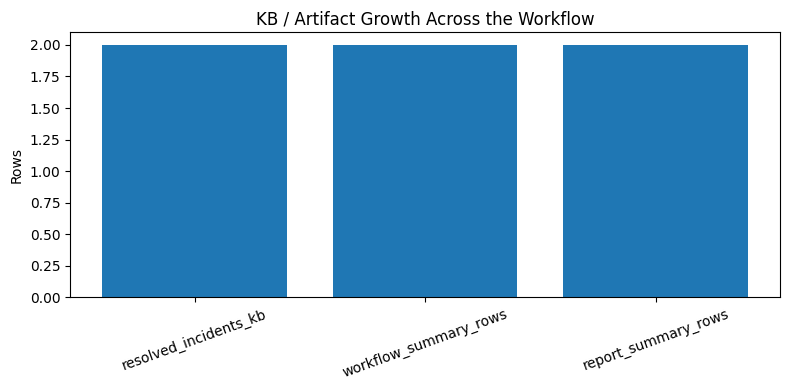

In [12]:
with timed_step('kb_growth_display'):
    if not kb_df.empty:
        display(kb_df[['incident_id', 'services', 'anomaly_type', 'root_cause_hypothesis', 'confidence']])
        growth_rows = [
            {'stage': 'resolved_incidents_kb', 'rows': len(kb_df)},
            {'stage': 'workflow_summary_rows', 'rows': len(workflow_summary_df)},
            {'stage': 'report_summary_rows', 'rows': len(report_summary_df)},
        ]
        growth_df = pd.DataFrame(growth_rows)
        display(growth_df)
        plt.figure(figsize=(8, 4))
        plt.bar(growth_df['stage'], growth_df['rows'])
        plt.title('KB / Artifact Growth Across the Workflow')
        plt.ylabel('Rows')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
    else:
        print('KB is empty')


## Section 6 – Timing & GPU Metrics

Summarize end-to-end latency and per-step timings captured during the demo notebook execution.


In [13]:
metrics_df_demo = pd.DataFrame(metrics_log)
metrics_df_demo


,step,elapsed_sec,gpu_before_cmd,gpu_before,gpu_after_cmd,gpu_after
0,problem_data_overview,0.1832,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
1,incident_list_view,0.1947,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
2,anomaly_plot,0.5811,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
3,similarity_search,17.3084,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
4,similarity_search,0.1965,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
5,rca_remediation_display,0.2239,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
6,final_report_display,0.1754,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."
7,kb_growth_display,0.3128,rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe...",rocm-smi --showuse --showmemuse --showtemp --csv,"device,Temperature (Sensor junction) (C),Tempe..."


,end_to_end_latency_sec
0,19.176


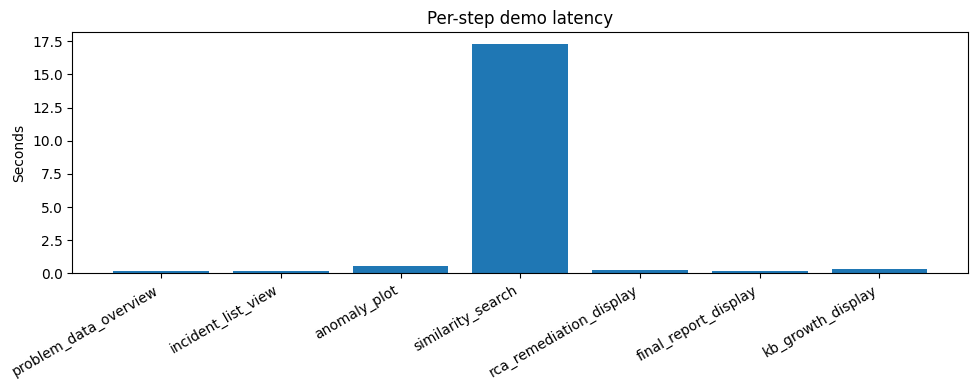

In [14]:
if not metrics_df_demo.empty:
    total_latency = metrics_df_demo['elapsed_sec'].sum()
    display(pd.DataFrame([{'end_to_end_latency_sec': round(total_latency, 4)}]))
    plt.figure(figsize=(10, 4))
    plt.bar(metrics_df_demo['step'], metrics_df_demo['elapsed_sec'])
    plt.title('Per-step demo latency')
    plt.ylabel('Seconds')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No timing data captured yet')


In [15]:
if not metrics_df_demo.empty:
    latest_gpu = metrics_df_demo.iloc[-1]['gpu_after']
    print('Latest GPU snapshot:')
    print(latest_gpu)
else:
    print('No GPU snapshots captured yet')


Latest GPU snapshot:
device,Temperature (Sensor junction) (C),Temperature (Sensor memory) (C),GPU use (%),GPU Memory Allocated (VRAM%),GPU Memory Read/Write Activity (%),Memory Activity
card0,48.0,41.0,0,92,0,N/A




## Section 7 – Demo Closing Notes

Use these bullets as a verbal wrap-up during the hackathon demo.


In [16]:
display(Markdown('''
### Key takeaways
- The notebook shows an end-to-end AIOps loop: detection, retrieval, RCA, remediation, reporting, and KB growth.
- The solution uses AMD GPU-backed model serving / embeddings for semantic reasoning and retrieval.
- The workflow is modular: each stage can later be productionized behind services, schedulers, and real infrastructure integrations.
- The demo keeps execution safe by using policy-aware mock actions while preserving realistic orchestration and auditability.
'''))



### Key takeaways
- The notebook shows an end-to-end AIOps loop: detection, retrieval, RCA, remediation, reporting, and KB growth.
- The solution uses AMD GPU-backed model serving / embeddings for semantic reasoning and retrieval.
- The workflow is modular: each stage can later be productionized behind services, schedulers, and real infrastructure integrations.
- The demo keeps execution safe by using policy-aware mock actions while preserving realistic orchestration and auditability.
